In [27]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def create_and_insert():
    
    conn = sqlite3.connect('sales.db', timeout=20)
    cursor = conn.cursor()
    
    
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        name TEXT,
        state TEXT,
        sales REAL,
        
    )
    ''')
    
    
    cursor.execute("SELECT COUNT(*) FROM sales")
    count = cursor.fetchone()[0]
    
    if count == 0:
        
        sale = [
            (1, 'Brendan Murry', 'Maryland', 73.94),
            (2, 'Jane Doe', 'California', 85.43),
            (3, 'John Smith', 'Texas', 92.30),
            (4, 'Sarah Johnson', 'New York', 67.82),
            (5, 'Michael Brown', 'Florida', 54.19)
        ]
        
        
        cursor.executemany("INSERT INTO sales (id, name, state, sales) VALUES (?, ?, ?, ?)", sale)
        print("Data inserted successfully!")
    else:
        print(f"Data already exists ({count} records). Skipping insert.")
    
    
    conn.commit()
    conn.close()

In [15]:
conn = sqlite3.connect('sales.db')
query = "select * from Sales"
df = pd.read_sql(query,conn)
df.head()

,id,name,state,amount
0,1,Brendan Murry,Maryland,73.94
1,2,Jane Doe,California,85.43
2,3,John Smith,Texas,92.30
3,4,Sarah Johnson,New York,67.82
4,5,Michael Brown,Florida,54.19


In [16]:
conn = sqlite3.connect('sales.db')
query = f"""
    SELECT id, name, state, amount
    FROM sales
    ORDER BY amount DESC
    LIMIT {2}
    """
df = pd.read_sql(query,conn)
df.head()

,id,name,state,amount
0,3,John Smith,Texas,92.30
1,2,Jane Doe,California,85.43


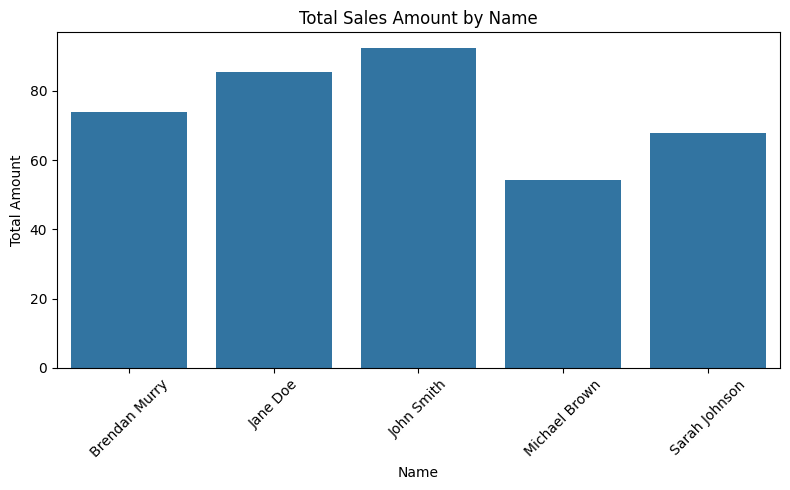

In [25]:
query = "SELECT name, SUM(amount) AS total_amount FROM sales GROUP BY name"
df_sales = pd.read_sql(query, conn)

plt.figure(figsize=(8, 5))
sns.barplot(x="name", y="total_amount", data=df_sales)
plt.xticks(rotation=45)
plt.xlabel("Name")
plt.ylabel("Total Amount")
plt.title("Total Sales Amount by Name")
plt.tight_layout()
plt.show()

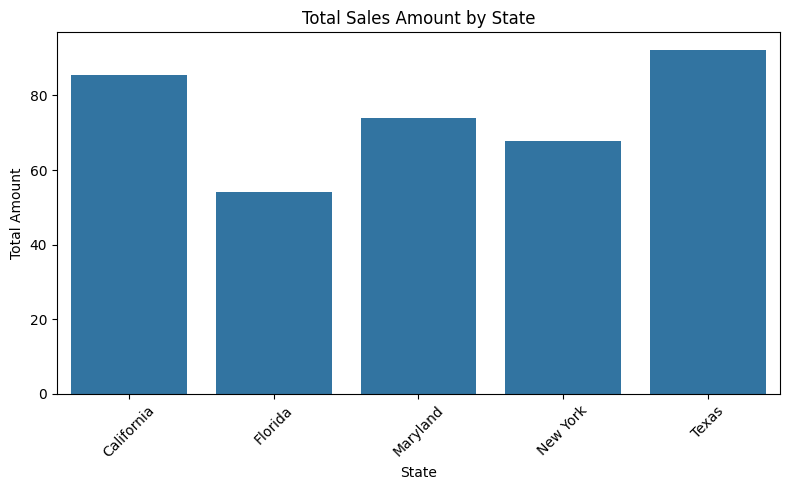

In [26]:
query = "SELECT state, SUM(amount) AS total_amount FROM sales GROUP BY state"
df_sales = pd.read_sql(query, conn)

plt.figure(figsize=(8, 5))
sns.barplot(x="state", y="total_amount", data=df_sales)
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Total Amount")
plt.title("Total Sales Amount by State")
plt.tight_layout()
plt.show()